# Demo

## `compute_dark_diversity()` Function Arguments

```python
compute_dark_diversity(
    y,                      # Species presence-absence matrix (n_sites, n_species)
    x,                      # Environmental predictor matrix (n_sites, n_env)
    model_type="linear",    # "linear" | "gaussian" | "bnn"
    num_factors=1,          # Number of latent factors for residual covariance
    method="svi",           # "svi" | "mcmc"
    cuda=False,             # GPU computation (SVI only)
    include_latent=True,    # Include latent factors in predictions
    return_means=True,      # Return means or full posterior samples
    batch_size=None,        # Mini-batch size for SVI training (default: None)
    pred_batch_size=None,   # Site-chunk size for prediction output (default: None)
    categorical_cols=None,  # List of column names to treat as categorical
)
```

### Parameter Details

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `y` | array | — | Species presence-absence matrix with shape `(n_sites, n_species)` |
| `x` | array | — | Environmental predictor matrix with shape `(n_sites, n_env)` |
| `model_type` | str | `"linear"` | Ecological response model: `"linear"`, `"gaussian"`, or `"bnn"` |
| `num_factors` | int | `1` | Number of latent factors used to model residual species covariance |
| `method` | str | `"svi"` | Inference method: `"svi"` (Stochastic Variational Inference) or `"mcmc"` (Hamiltonian NUTS) |
| `cuda` | bool | `False` | Use GPU computation (SVI only, requires CUDA) |
| `include_latent` | bool | `True` | Include latent factors when computing probabilities |
| `return_means` | bool | `True` | Return posterior means (True) or full posterior samples (False) |
| `batch_size` | int | `None` | Mini-batch size for SVI training (None fits all data in one step) |
| `pred_batch_size` | int | `None` | Site-chunk size for prediction output (None uses full-batch prediction) |
| `categorical_cols` | list or None | `None` | List of column names in `x` to treat as categorical variables |

### Handling Categorical Data

The function can automatically detect and one-hot encode categorical variables. You can:

1. **Explicitly specify categorical columns** using `categorical_cols`:
   ```python
   compute_dark_diversity(y, x, categorical_cols=["landuse", "soil_type"])
   ```

2. **Auto-detect categorical columns** based on pandas dtype (category, object, bool, string)

3. **Convert to categorical type** before passing to the function:
   ```python
   x["landuse"] = x["landuse"].astype("category")
   compute_dark_diversity(y, x)  # landuse will be auto-detected
   ```

Continuous variables are automatically standardized, while categorical variables are one-hot encoded.

### Method-Specific Arguments

**SVI:**
- `num_iterations=2500` — Number of training iterations
- `lr=0.01` — Learning rate
- `num_samples=1000` — Number of posterior samples
- `batch_size=None` — Mini-batch size for SVI (default: None for full-batch)
- `pred_batch_size=None` — Site-chunk size for prediction output (default: None for full-batch)

**MCMC:**
- `num_samples=1000` — Number of posterior samples
- `warmup_steps=500` — Warmup/burn-in steps

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Main function
from pmf_dark import compute_dark_diversity

# Extra functions (plots/evaluation)
from extras.plots import plot_spatial_predictions
from extras.plots import plot_environmental_response
from extras.plots import plot_spatial_uncertainty
from extras.evaluation import compute_overall_error_metrics
from extras.evaluation import compute_species_error_metrics
from extras.evaluation import plot_metric_boxplots


pmf-dark: CUDA is not available. Using CPU.


c:\Users\dyshe\Git projects\pmf_dark\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prepare input data - pandas dataframes

In [3]:
# Import survey data
y = pd.read_csv("data/survey.csv", index_col=0)
coords = y[["x", "y"]]
y = y.drop(columns=["x", "y", "ID"])
# Rows: sites, Columns: species, Values: presence/absence (1/0)


# Import environmental data
x = pd.read_csv("data/env.csv", index_col=0)
x = x.drop(columns=["landuse", "ID"])
# Rows: sites, Columns: environmental variables, Values: measurements

## 1) Linear model - SVI vs MCMC

In [4]:
p_linear_svi = compute_dark_diversity(y, x, model_type="linear", method = "svi", include_latent = False, batch_size = 100, num_iterations = 2500)

presence_absence
Using device: cpu
Iteration 0 - Loss: 16954.23
Iteration 500 - Loss: 5133.77
Iteration 1000 - Loss: 5305.53
Iteration 1500 - Loss: 5092.25
Iteration 2000 - Loss: 5457.82
SVI converged successfully.


In [5]:
p_linear_mcmc = compute_dark_diversity(y, x, model_type="linear", method = "mcmc", include_latent = False)

presence_absence


Sample: 100%|██████████| 1500/1500 [05:09,  4.84it/s, step size=1.63e-01, acc. prob=0.865]


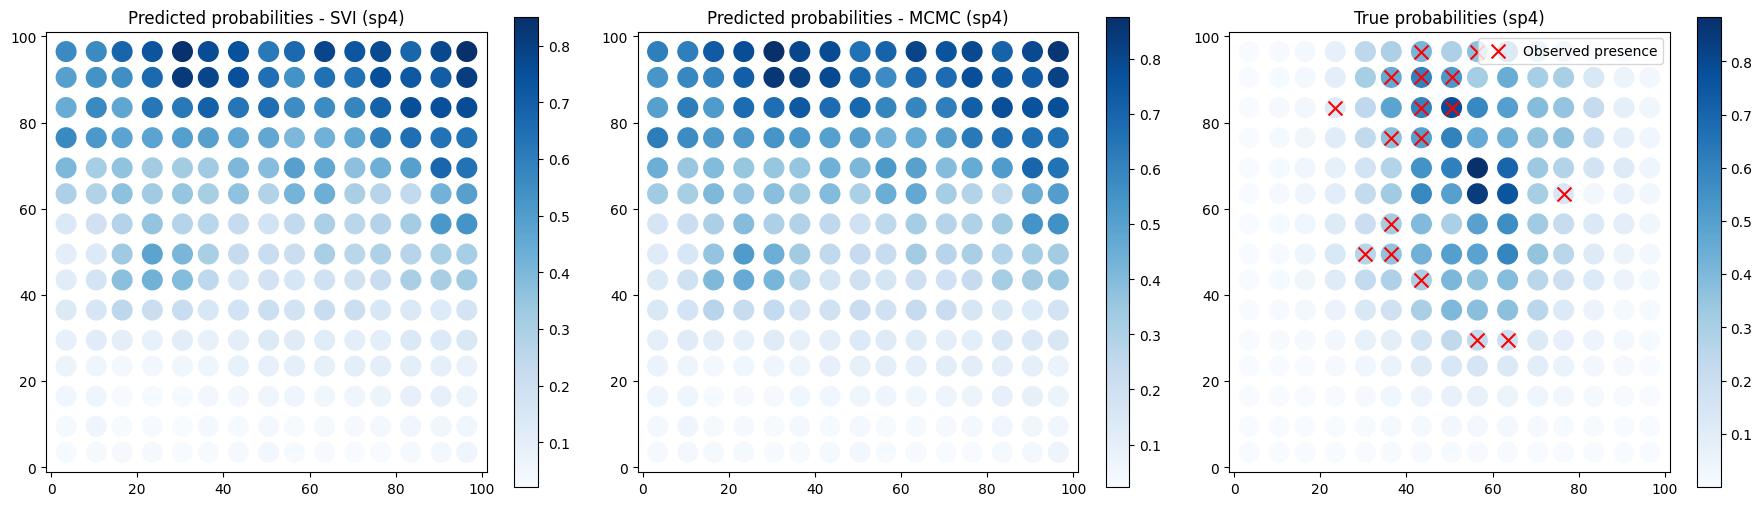

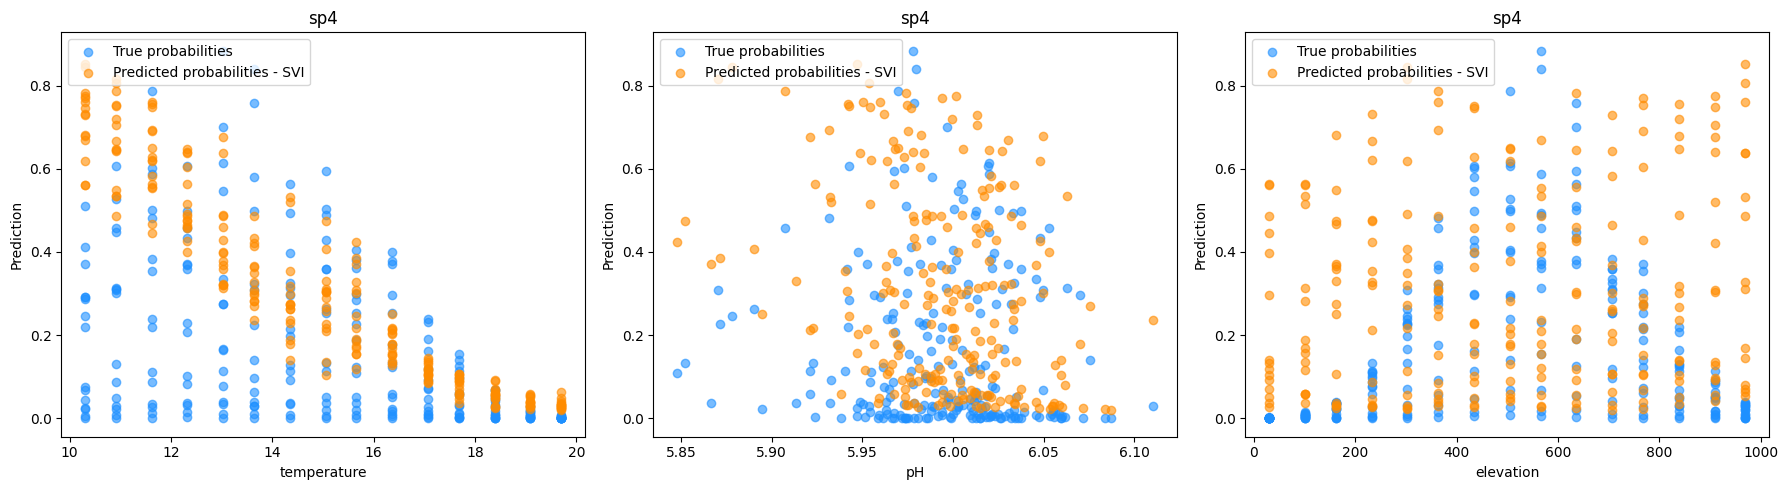

In [6]:
# load the true values
true_values = pd.read_csv("data/truth.csv", index_col=0) # Rows: sites, Columns: species, Values: true probabilities
pool_darkdiv = pd.read_csv("data/pool_darkdiv.csv", index_col=0) # Rows: sites, Columns: species, Values: darkdiv R package predictions

# Select a species to plot
species_idx = 3
plot_spatial_predictions(coords, [p_linear_svi, p_linear_mcmc, true_values], species_idx, 
                         labels=["Predicted probabilities - SVI", 
                                 "Predicted probabilities - MCMC", 
                                 "True probabilities"],
                                 y = y, presence_ax = [2]) # Plot survey data on top on axis 2

plot_environmental_response(x, [true_values, p_linear_svi], species_idx=species_idx,
                            labels=["True probabilities", 
                                    "Predicted probabilities - SVI"],
                            colors = ["dodgerblue", "darkorange"]
                                    )


## 2) Gaussian response model

We model species occurrence using a Bernoulli distribution with a logit link:

$$
Y_{ij} \sim \text{Bernoulli}(p_{ij})
$$

where

$$
p_{ij} = \text{logit}^{-1}(\eta_{ij})
$$

and the linear predictor is given by

$$
\eta_{ij}
=
\alpha_j
-
\sum_{k=1}^{K}
\gamma_{kj}
\left(
X_{ik} - \mu_{kj}
\right)^2
+
\mathbf{W}_i^\top \mathbf{Z}_j
$$

where:

- $i = 1, \dots, n_{\text{sites}}$
- $j = 1, \dots, n_{\text{species}}$
- $k = 1, \dots, n_{\text{env}}$


In [7]:
# Include latent variables in the predictions
p_gaus_latent = compute_dark_diversity(y, x, model_type="gaussian",
                            method = "svi", include_latent = True)

# Do not include latent variables in the predictions
p_gaus_no_latent = compute_dark_diversity(y, x, model_type="gaussian",
                            method = "svi", include_latent = False)

presence_absence
Using device: cpu
Iteration 0 - Loss: 9174.77
Iteration 500 - Loss: 4629.61
Iteration 1000 - Loss: 4649.57
Iteration 1500 - Loss: 4632.82
Iteration 2000 - Loss: 4604.82
SVI converged successfully.
presence_absence
Using device: cpu
Iteration 0 - Loss: 9106.19
Iteration 500 - Loss: 4623.81
Iteration 1000 - Loss: 4641.31
Iteration 1500 - Loss: 4619.24
Iteration 2000 - Loss: 4653.78
SVI converged successfully.


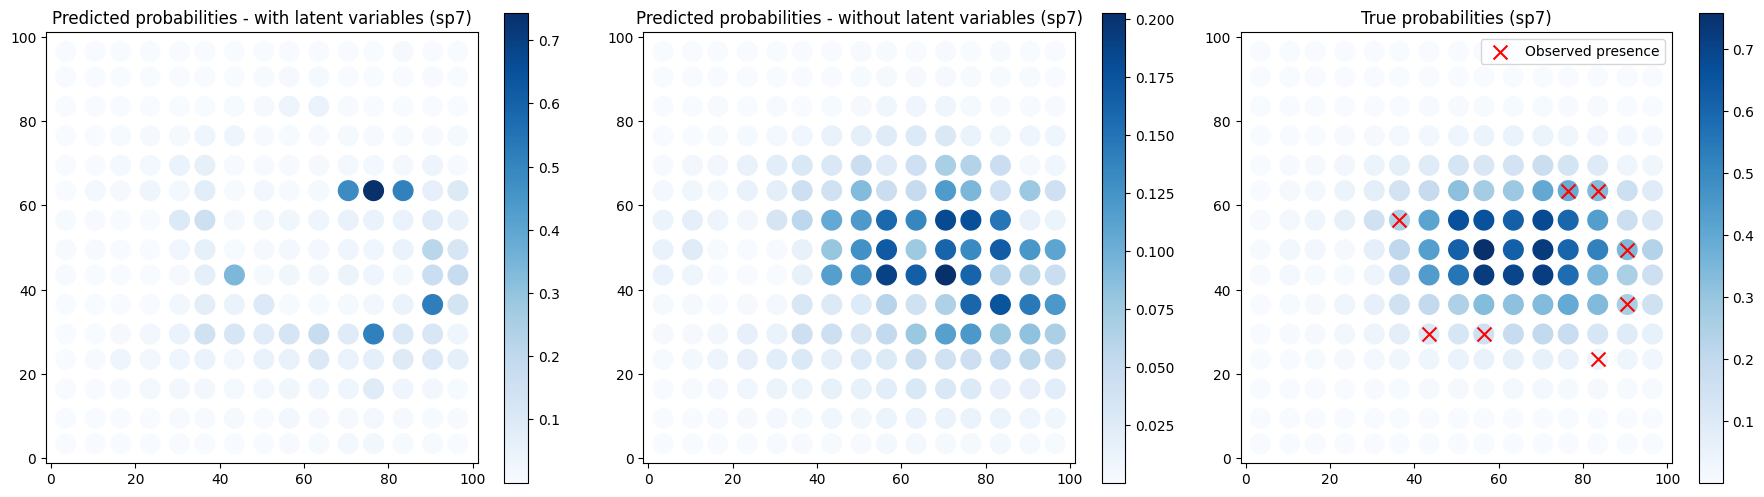

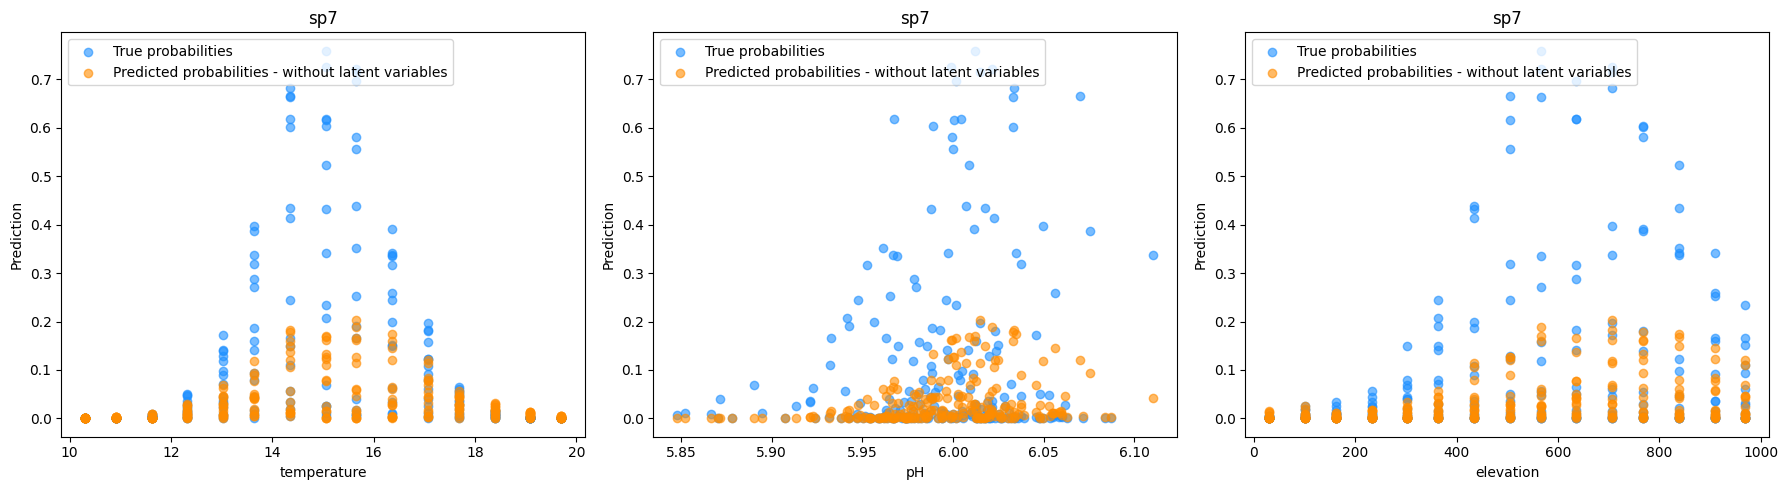

In [8]:
# Select a species to plot
species_idx = 6
plot_spatial_predictions(coords, [p_gaus_latent, p_gaus_no_latent, true_values], species_idx, 
                         labels=["Predicted probabilities - with latent variables", 
                                 "Predicted probabilities - without latent variables", 
                                 "True probabilities"],
                                 y = y, presence_ax = [2]) # Plot survey data on top on axis 2

plot_environmental_response(x, [true_values, p_gaus_no_latent], species_idx=species_idx,
                            labels=["True probabilities", 
                                    "Predicted probabilities - without latent variables"],
                            colors = ["dodgerblue", "darkorange"]
                                    )


## 3) Performance - Linear vs Gaussian model

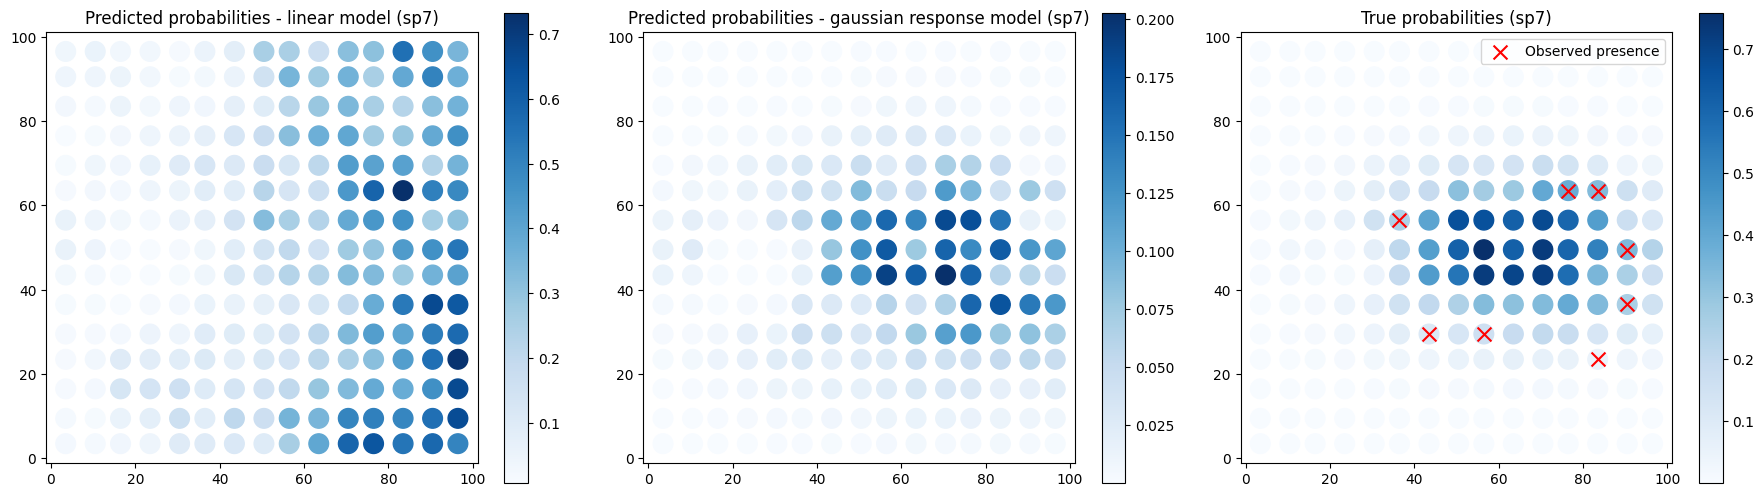

In [9]:
# compare p_linear_svi and p_gaus_no_latent
plot_spatial_predictions(coords, [p_linear_svi, p_gaus_no_latent, true_values], species_idx, 
                         labels=["Predicted probabilities - linear model", 
                                 "Predicted probabilities - gaussian response model",
                                 "True probabilities"],
                                 y = y, presence_ax = [2]) # Plot survey data on top on axis 2

In [10]:
# Overall metrics
metrics_linear_svi = compute_overall_error_metrics(p_linear_svi, true_values)
metrics_gaus_no_latent = compute_overall_error_metrics(p_gaus_no_latent, true_values)
# Drop NaN rows from pool_darkdiv and align true_values for R darkdiv comparison
pool_darkdiv_clean = pool_darkdiv.dropna()
true_values_darkdiv = true_values.loc[pool_darkdiv_clean.index]
metrics_darkdiv = compute_overall_error_metrics(pool_darkdiv_clean, true_values_darkdiv)

metrics_df = pd.DataFrame({"Metric": list(metrics_linear_svi.keys()),
                           "Linear": list(metrics_linear_svi),
                           "Gaussian": list(metrics_gaus_no_latent),
                           "R darkdiv": list(metrics_darkdiv)})
print(metrics_df)


        Metric    Linear  Gaussian  R darkdiv
0          MSE  0.060551  0.018095   0.345761
1         RMSE  0.246071  0.134518   0.588015
2          MAE  0.172893  0.067269   0.506972
3  Correlation  0.497914  0.788465   0.478264


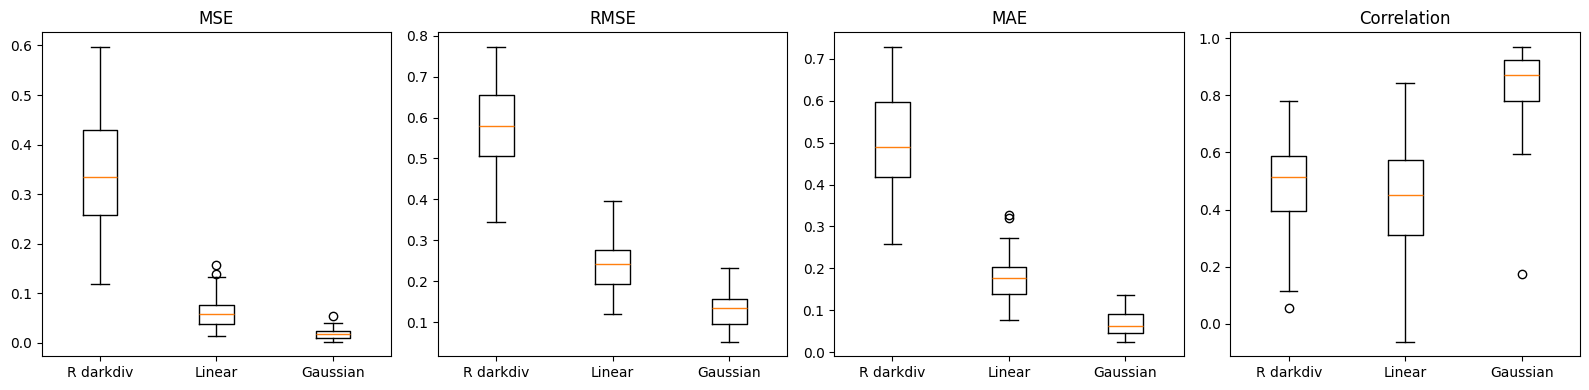

In [11]:
# Species metrics
metrics_species_linear_svi = compute_species_error_metrics(p_linear_svi, true_values)
metrics_species_gaus_no_latent = compute_species_error_metrics(p_gaus_no_latent, true_values)
# Drop NaN rows from pool_darkdiv and align true_values for R darkdiv comparison
pool_darkdiv_clean = pool_darkdiv.dropna()
true_values_darkdiv = true_values.loc[pool_darkdiv_clean.index]
metrics_species_darkdiv = compute_species_error_metrics(pool_darkdiv_clean, true_values_darkdiv)
plot_metric_boxplots(metric_dfs=[metrics_species_darkdiv, metrics_species_linear_svi, metrics_species_gaus_no_latent], labels=["R darkdiv","Linear","Gaussian"],)


## 4) Optimal number of factors?

In [ ]:
results = {}

K = 5

for num_factors in range(0,K):
    print(f"Computing dark diversity with {num_factors} latent factors...")
    model_type=f"gaussian_{num_factors}_factors"

    probabilities = compute_dark_diversity(
        y,
        x,
        model_type="gaussian",
        num_factors=num_factors,
        method="svi",
        include_latent=False,
    )

    results[model_type] = probabilities
    print('\n')


Computing dark diversity with 0 latent factors...
presence_absence
Using device: cpu
Iteration 0 - Loss: 9199.52
Iteration 500 - Loss: 4823.99
Iteration 1000 - Loss: 4817.65
Iteration 1500 - Loss: 4824.57
Iteration 2000 - Loss: 4827.39
SVI converged successfully.


Computing dark diversity with 1 latent factors...
presence_absence
Using device: cpu
Iteration 0 - Loss: 10130.48
Iteration 500 - Loss: 4652.34
Iteration 1000 - Loss: 4649.50
Iteration 1500 - Loss: 4624.50
Iteration 2000 - Loss: 4636.88
SVI converged successfully.


Computing dark diversity with 2 latent factors...
presence_absence
Using device: cpu
Iteration 0 - Loss: 10454.78
Iteration 500 - Loss: 4738.50
Iteration 1000 - Loss: 4727.97
Iteration 1500 - Loss: 4701.09
Iteration 2000 - Loss: 4684.55
SVI converged successfully.


Computing dark diversity with 3 latent factors...
presence_absence
Using device: cpu
Iteration 0 - Loss: 10901.40
Iteration 500 - Loss: 4823.31
Iteration 1000 - Loss: 4798.54
Iteration 1500 - Loss: 47

In [12]:
metrics = {}

for k, result in results.items():
    # compute over all metrics
    metrics[k] = compute_overall_error_metrics(
        result,
        true_values,
    )

metrics_df = pd.DataFrame(metrics).T
metrics_df.index = [f"{i} latent factors" for i in range(0,K)]
print(metrics_df)

                       MSE      RMSE       MAE  Correlation
0 latent factors  0.013455  0.115995  0.057337     0.872733
1 latent factors  0.015816  0.125760  0.061768     0.858231
2 latent factors  0.016497  0.128442  0.063200     0.857769
3 latent factors  0.016859  0.129842  0.063712     0.857654
4 latent factors  0.017686  0.132988  0.065174     0.852554


## 5) Bayesian Neural Network

In [13]:
# Bayesian neural network
p_bnn = compute_dark_diversity(y, x, model_type="bnn",
                            method = "svi", include_latent = False, cuda = True, hidden_size=16)

presence_absence
Using device: cuda
Iteration 0 - Loss: 21103.81
Iteration 500 - Loss: 7179.31
Iteration 1000 - Loss: 6721.19
Iteration 1500 - Loss: 6622.91
Iteration 2000 - Loss: 6522.05
SVI converged successfully.


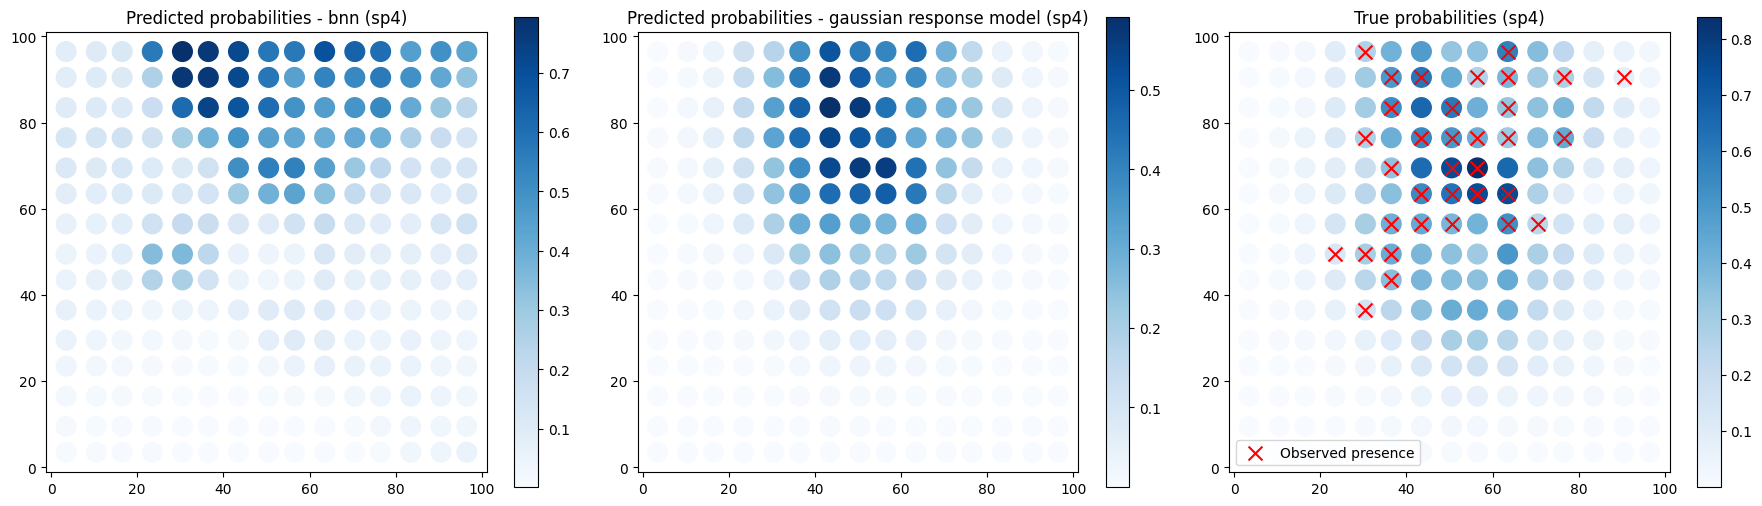

In [14]:
# compare p_linear_svi and p_bnn
plot_spatial_predictions(coords, [p_bnn, p_gaus_no_latent, true_values], species_idx, 
                         labels=["Predicted probabilities - bnn", 
                                 "Predicted probabilities - gaussian response model",
                                 "True probabilities"],
                                 y = y, presence_ax = [2]) # Plot survey data on top on axis 2

In [15]:
# Overall metrics
metrics_linear_svi = compute_overall_error_metrics(p_linear_svi, true_values)
metrics_gaus_no_latent = compute_overall_error_metrics(p_gaus_no_latent, true_values)
metrics_bnn_no_latent = compute_overall_error_metrics(p_bnn, true_values)
# Drop NaN rows from pool_darkdiv and align true_values for R darkdiv comparison
pool_darkdiv_clean = pool_darkdiv.dropna()
true_values_darkdiv = true_values.loc[pool_darkdiv_clean.index]
metrics_darkdiv = compute_overall_error_metrics(pool_darkdiv_clean, true_values_darkdiv)

metrics_df = pd.DataFrame({"Metric": list(metrics_linear_svi.keys()),
                           "Linear": list(metrics_linear_svi),
                           "Gaussian": list(metrics_gaus_no_latent),
                           "BNN": list(metrics_bnn_no_latent),
                           "R darkdiv": list(metrics_darkdiv)})
print(metrics_df)


        Metric    Linear  Gaussian       BNN
0          MSE  0.070720  0.015767  0.031858
1         RMSE  0.265932  0.125568  0.178488
2          MAE  0.183978  0.062011  0.109104
3  Correlation  0.513437  0.858596  0.601716


## 6) Distrbution of $p$

In [16]:
p_gaus_samples = compute_dark_diversity(y, x, model_type="gaussian",
                            method = "svi", include_latent = False, return_means = False)

presence_absence
Using device: cpu
Iteration 0 - Loss: 11758.18
Iteration 500 - Loss: 5584.76
Iteration 1000 - Loss: 5652.79
Iteration 1500 - Loss: 5635.29
Iteration 2000 - Loss: 5608.82
SVI converged successfully.


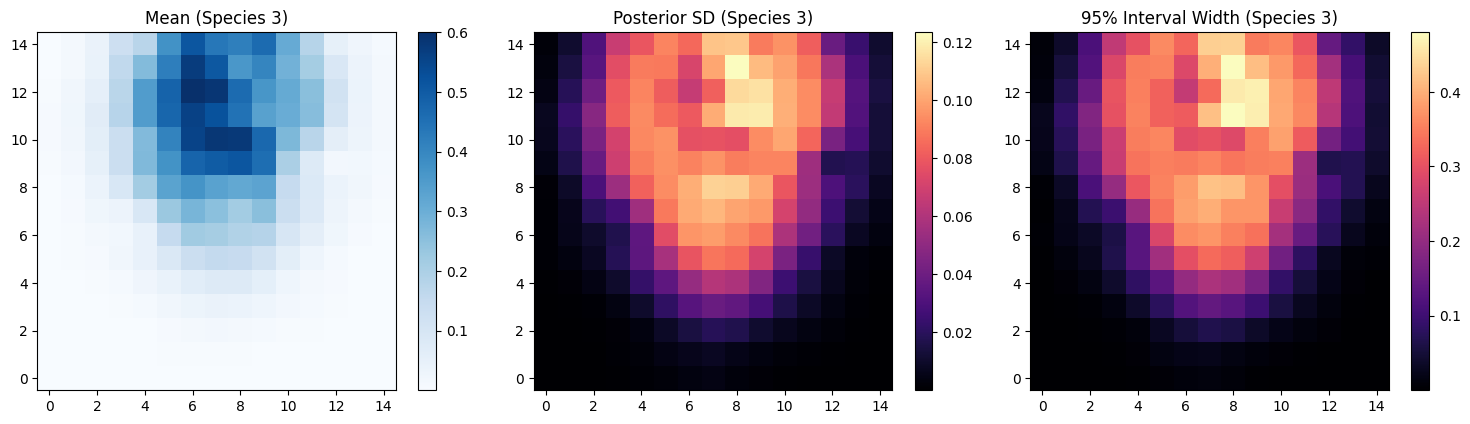

In [17]:
plot_spatial_uncertainty(
    p_gaus_samples,
    species_idx=3,
    grid_shape=(15, 15),
)

## 7) Count data

In [25]:
# Import survey data
y = pd.read_csv("data/survey_counts.csv", index_col=0)
coords = y[["x", "y"]].values
y = y.drop(columns=["x", "y"]) 
# Rows: sites, Columns: species, Values: Number of occurences

count_gaus = compute_dark_diversity(y, x, model_type="gaussian", num_factors=1,
                            method = "svi", include_latent = False, return_means = True)

count
Using device: cpu
Iteration 0 - Loss: 97344.23
Iteration 500 - Loss: 21059.23
Iteration 1000 - Loss: 19296.01
Iteration 1500 - Loss: 18068.12
Iteration 2000 - Loss: 17983.89
SVI converged successfully.


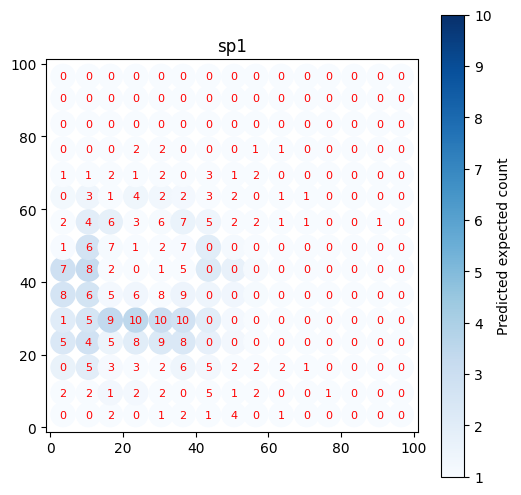

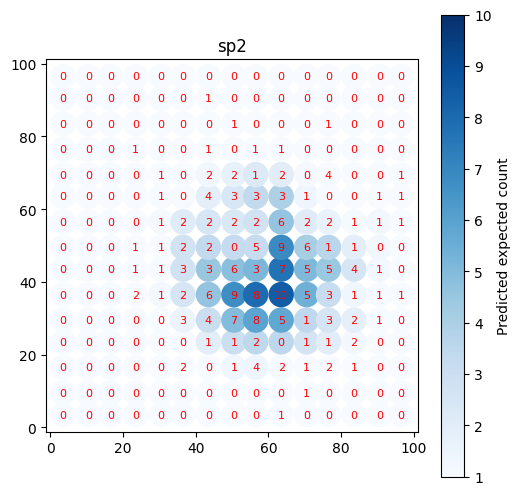

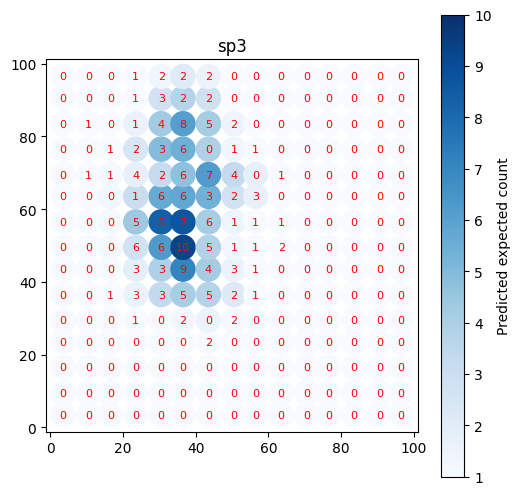

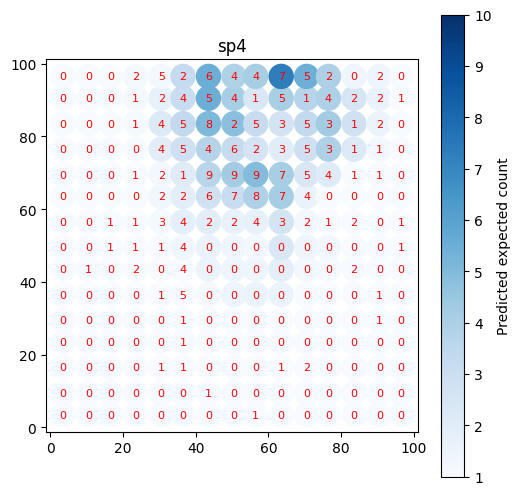

In [26]:
for species_idx in range(0, 4):

    species = y.columns[species_idx]

    plt.figure(figsize=(6, 6))

    sc = plt.scatter(
        coords[:, 0],
        coords[:, 1],
        c=count_gaus.iloc[:, species_idx],
        cmap="Blues",
        s=300,
        vmin=1,
        vmax=10,
    )

    plt.colorbar(
        sc,
        label="Predicted expected count",
    )

    # Add observed counts
    for i in range(len(coords)):

        plt.text(
            coords[i, 0],
            coords[i, 1],
            str(y.iloc[i, species_idx]),
            ha="center",
            va="center",
            fontsize=8,
            color="red",
        )

    plt.gca().set_aspect("equal")

    plt.title(species)

    plt.show()

## CUDA vs CPU performance

In [4]:
## CUDA vs CPU performance

p_gaus_cpu = compute_dark_diversity(
    y, 
    x, 
    model_type="gaussian",
    method = "svi", 
    cuda = False,
    include_latent = False
)

p_gaus_cuda = compute_dark_diversity(
    y,
    x,
    model_type="gaussian",
    method="svi",
    cuda=True,
    include_latent=False,
)

presence_absence
Using device: cpu
Iteration 0 - Loss: 9754.98
Iteration 500 - Loss: 4638.65
Iteration 1000 - Loss: 4632.76
Iteration 1500 - Loss: 4648.87
Iteration 2000 - Loss: 4589.06
SVI converged successfully.
presence_absence
Using device: cuda
Iteration 0 - Loss: 9906.28
Iteration 500 - Loss: 4681.55
Iteration 1000 - Loss: 4601.81
Iteration 1500 - Loss: 4669.02
Iteration 2000 - Loss: 4612.13
SVI converged successfully.
